In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from gensim.models import Word2Vec
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Скачиваем NLTK данные (один раз)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

sns.set_theme(style="whitegrid", font_scale=1.1)

df = pd.read_csv('datasets/spam.csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

print(f"Датасет SMS Spam: {len(df)} сообщений")
print(f"Классы: {df['label'].value_counts().to_dict()}")
print("\nПримеры:")
print(df.head(10))

Датасет SMS Spam: 5572 сообщений
Классы: {'ham': 4825, 'spam': 747}

Примеры:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
5  spam  FreeMsg Hey there darling it's been 3 week's n...
6   ham  Even my brother is not like to speak with me. ...
7   ham  As per your request 'Melle Melle (Oru Minnamin...
8  spam  WINNER!! As a valued network customer you have...
9  spam  Had your mobile 11 months or more? U R entitle...


In [3]:
# Токенизация и очистка
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Токенизация, lowercase, удаление stopwords и знаков препинания"""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

# Применяем к каждому сообщению
df['tokens'] = df['text'].apply(preprocess)

print("Пример токенизации:")
for i in range(3):
    print(f"\nОригинал: {df.iloc[i]['text'][:80]}...")
    print(f"Токены:   {df.iloc[i]['tokens'][:15]}")

# Подготовка корпуса для Word2Vec (список списков токенов)
sentences = df['tokens'].tolist()
print(f"\n✅ Корпус готов: {len(sentences)} документов")

# Статистика
vocab_size = len(set([word for sent in sentences for word in sent]))
avg_len = np.mean([len(s) for s in sentences])
print(f"  Размер словаря: {vocab_size:,} уникальных слов")
print(f"  Средняя длина документа: {avg_len:.1f} токенов")

Пример токенизации:

Оригинал: Go until jurong point, crazy.. Available only in bugis n great world la e buffet...
Токены:   ['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore']

Оригинал: Ok lar... Joking wif u oni......
Токены:   ['ok', 'lar', 'joking', 'wif', 'u', 'oni']

Оригинал: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...
Токены:   ['free', 'entry', 'wkly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'may', 'text', 'fa', 'receive', 'entry', 'question']

✅ Корпус готов: 5572 документов
  Размер словаря: 7,156 уникальных слов
  Средняя длина документа: 8.4 токенов


In [8]:
# Обучаем Word2Vec (Skip-gram)
model = Word2Vec(
    sentences=sentences,      # Корпус (список списков токенов)
    size=100,                 # Размерность embeddings (обычно 100-300) vector_size в gs 4+
    window=5,                 # Контекстное окно (5 слов слева и справа)
    min_count=2,              # Игнорируем слова, встречающиеся < 2 раз
    workers=4,                # Параллельные потоки
    sg=1,                     # Skip-gram (1) или CBOW (0)
    iter=10,                  # Количество эпох обучения    epoch в gs 4+
    seed=42
)

print("✅ Модель Word2Vec обучена!")
print(f"  Размер словаря: {len(model.wv.vocab):,} слов")

# Примеры векторов
print("\n📊 Вектор слова 'call' (первые 10 измерений):")
print(model.wv['call'])

✅ Модель Word2Vec обучена!
  Размер словаря: 3,568 слов

📊 Вектор слова 'call' (первые 10 измерений):
[ 4.9473885e-01 -1.6359422e-01 -4.1379169e-01 -2.8698587e-01
  5.0888485e-01 -1.4501987e-01  3.8265064e-01  7.2943233e-02
 -1.6171810e-01  3.7221107e-01 -1.9262329e-01 -6.9688000e-02
 -9.1511518e-04 -2.2143124e-01 -4.3404120e-01  2.4157448e-01
  3.5385621e-01 -1.6196734e-01 -7.4226993e-01  7.2742393e-04
  3.1044573e-01  2.5509155e-01  4.9205166e-01 -2.5039828e-01
  4.0748261e-02  1.7661223e-01 -1.3257656e-02  2.4083992e-02
  4.5113143e-02 -2.6389551e-01 -2.2271055e-01  1.5813619e-02
  7.6726079e-02  1.2784557e-01 -1.5655069e-01 -1.1599827e-01
  1.7651710e-01  5.9269714e-01 -1.9629771e-01 -6.5147597e-01
  2.8333006e-02 -2.9899710e-01 -3.8603300e-01 -2.5701573e-01
  1.8949308e-01 -1.8371825e-01 -1.0794748e-01  2.8083131e-01
 -1.1140193e-02 -1.2077501e-01  2.3393273e-01 -3.1683445e-01
  2.7196103e-01  1.1084210e-01  5.6166762e-01 -2.3428643e-01
  8.1441343e-02 -1.5914995e-02 -2.6270127e-0

In [9]:
# Функция для поиска похожих слов
def find_similar(word, topn=10):
    """Находит topn самых похожих слов"""
    try:
        similar = model.wv.most_similar(word, topn=topn)
        print(f"\n🔍 Слова, похожие на '{word}':")
        for w, score in similar:
            print(f"  {w:15s}  similarity: {score:.3f}")
        return similar
    except KeyError:
        print(f"⚠️ Слово '{word}' не найдено в словаре")
        return []

# Тестируем на разных словах
find_similar('free', topn=10)
find_similar('call', topn=10)
find_similar('win', topn=10)

print("\n💡 Заметьте:")
print("  • Слова с похожим значением имеют высокую similarity (>0.7)")
print("  • Слова из спама часто группируются ('free', 'win', 'prize')")


🔍 Слова, похожие на 'free':
  colour           similarity: 0.972
  unlimited        similarity: 0.964
  ringtone         similarity: 0.961
  update           similarity: 0.957
  motorola         similarity: 0.956
  latest           similarity: 0.955
  bluetooth        similarity: 0.951
  flag             similarity: 0.951
  orange           similarity: 0.949
  deliveredtomorrow  similarity: 0.948

🔍 Слова, похожие на 'call':
  line             similarity: 0.904
  please           similarity: 0.892
  landline         similarity: 0.881
  quoting          similarity: 0.881
  valid            similarity: 0.880
  land             similarity: 0.880
  matches          similarity: 0.878
  match            similarity: 0.878
  code             similarity: 0.877
  expires          similarity: 0.875

🔍 Слова, похожие на 'win':
  chance           similarity: 0.980
  wkly             similarity: 0.948
  music            similarity: 0.942
  mates            similarity: 0.940
  wk               simil

Визуализируем 500 слов
Исходная размерность: (500, 100)
После t-SNE: (500, 2)


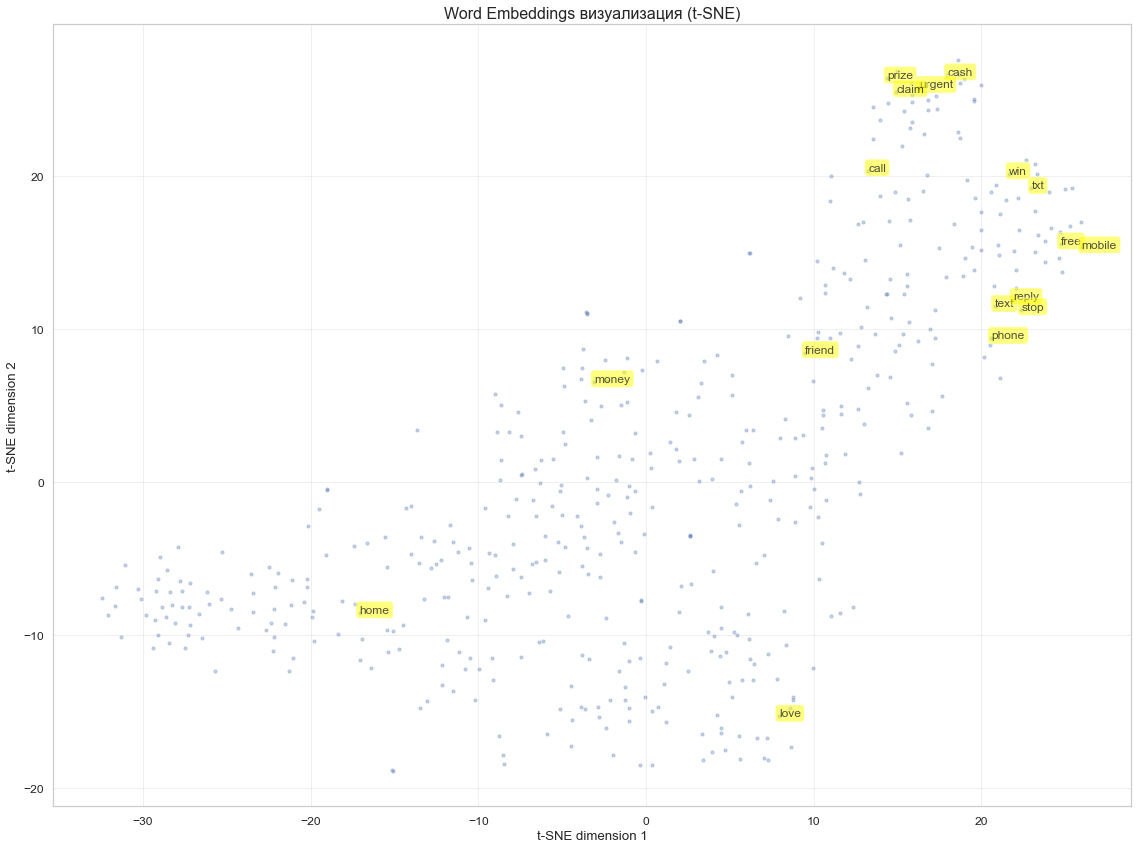


💡 Наблюдения:
  • Спам-слова ('free', 'win', 'prize') образуют КЛАСТЕР
  • Глаголы коммуникации ('call', 'text', 'reply') близко друг к другу
  • Модель без учителя разделила слова по семантике!


In [13]:
# Извлекаем векторы и слова
#words = list(model.wv.index_to_key[:500])  # Топ-500 самых частых слов gensim 4+
words = sorted(model.wv.vocab, key=lambda w: model.wv.vocab[w].count, reverse=True)[:500]
vectors = np.array([model.wv[w] for w in words])

print(f"Визуализируем {len(words)} слов")
print(f"Исходная размерность: {vectors.shape}")

# t-SNE: 100D → 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

print(f"После t-SNE: {vectors_2d.shape}")

# Визуализация
plt.figure(figsize=(16, 12))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.3, s=10)

# Подписываем интересные слова (вручную отобранные)
interesting_words = ['free', 'win', 'prize', 'call', 'text', 'love', 'home', 
                     'friend', 'money', 'cash', 'urgent', 'congratulations',
                     'mobile', 'phone', 'txt', 'reply', 'stop', 'claim']

for word in interesting_words:
    if word in words:
        idx = words.index(word)
        x, y = vectors_2d[idx]
        plt.annotate(word, (x, y), fontsize=12, alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.title('Word Embeddings визуализация (t-SNE)', fontsize=16)
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Наблюдения:")
print("  • Спам-слова ('free', 'win', 'prize') образуют КЛАСТЕР")
print("  • Глаголы коммуникации ('call', 'text', 'reply') близко друг к другу")
print("  • Модель без учителя разделила слова по семантике!")